In [240]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl
import numpy as np
import seaborn as sns
import math
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

# Data preparation

In [241]:
white_wine_df = pd.read_csv('winequality-white.csv', sep=';')
red_wine_df   = pd.read_csv('winequality-red.csv', sep=';')

white_wine_df['wine_type'] = 'white'
red_wine_df['wine_type'] = 'red'

In [242]:
def quality_label(quality: int):
    if 0 <= quality < 5: return 'low'
    if 5 <= quality < 7: return 'medium'
    return 'high'

white_wine_df['quality_label'] = white_wine_df['quality'].apply(quality_label)
red_wine_df['quality_label'] = red_wine_df['quality'].apply(quality_label)

In [243]:
df = pd.concat([white_wine_df, red_wine_df], ignore_index=True)
df = df.sample(frac=1, random_state=0).reset_index(drop=True)

df['quality_label'] = pd.Categorical(
    df['quality_label'],
    categories=['low', 'medium', 'high'],
    ordered=True
)

In [244]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type,quality_label
0,11.9,0.38,0.51,2.0,0.121,7.0,20.0,0.99960,3.24,0.76,10.4,6,red,medium
1,9.0,0.46,0.31,2.8,0.093,19.0,98.0,0.99815,3.32,0.63,9.5,6,red,medium
2,7.5,0.20,0.41,1.2,0.050,26.0,131.0,0.99133,3.19,0.52,11.1,5,white,medium
3,6.5,0.44,0.49,7.7,0.045,16.0,169.0,0.99570,3.11,0.37,8.7,6,white,medium
4,6.6,0.32,0.33,2.5,0.052,40.0,219.5,0.99316,3.15,0.60,10.0,5,white,medium


In [245]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   fixed acidity         6497 non-null   float64 
 1   volatile acidity      6497 non-null   float64 
 2   citric acid           6497 non-null   float64 
 3   residual sugar        6497 non-null   float64 
 4   chlorides             6497 non-null   float64 
 5   free sulfur dioxide   6497 non-null   float64 
 6   total sulfur dioxide  6497 non-null   float64 
 7   density               6497 non-null   float64 
 8   pH                    6497 non-null   float64 
 9   sulphates             6497 non-null   float64 
 10  alcohol               6497 non-null   float64 
 11  quality               6497 non-null   int64   
 12  wine_type             6497 non-null   object  
 13  quality_label         6497 non-null   category
dtypes: category(1), float64(11), int64(1), object(1)
memory 

In [246]:
subset_attributes = ['residual sugar', 'total sulfur dioxide', 'sulphates', 'alcohol', 'volatile acidity', 'quality']

df[subset_attributes].describe()

,residual sugar,total sulfur dioxide,sulphates,alcohol,volatile acidity,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,5.443235,115.744574,0.531268,10.491801,0.339666,5.818378
std,4.757804,56.521855,0.148806,1.192712,0.164636,0.873255
min,0.600000,6.000000,0.220000,8.000000,0.080000,3.000000
25%,1.800000,77.000000,0.430000,9.500000,0.230000,5.000000
50%,3.000000,118.000000,0.510000,10.300000,0.290000,6.000000
75%,8.100000,156.000000,0.600000,11.300000,0.400000,6.000000
max,65.800000,440.000000,2.000000,14.900000,1.580000,9.000000


In [247]:
subset_attributes = ['alcohol', 'volatile acidity', 'pH', 'quality_label']

df[subset_attributes].groupby('quality_label', observed=False).aggregate(['mean', 'std'])

alcohol           volatile acidity                  pH  \
                    mean       std             mean       std      mean   
quality_label                                                             
low            10.184350  0.999035         0.465163  0.245677  3.234797   
medium         10.265275  1.070626         0.346423  0.165660  3.215346   
high           11.433359  1.215620         0.289170  0.116960  3.227651   

                         
                    std  
quality_label            
low            0.191313  
medium         0.159461  
high           0.159094

# Univariate Analysis

In [248]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()

In [249]:
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

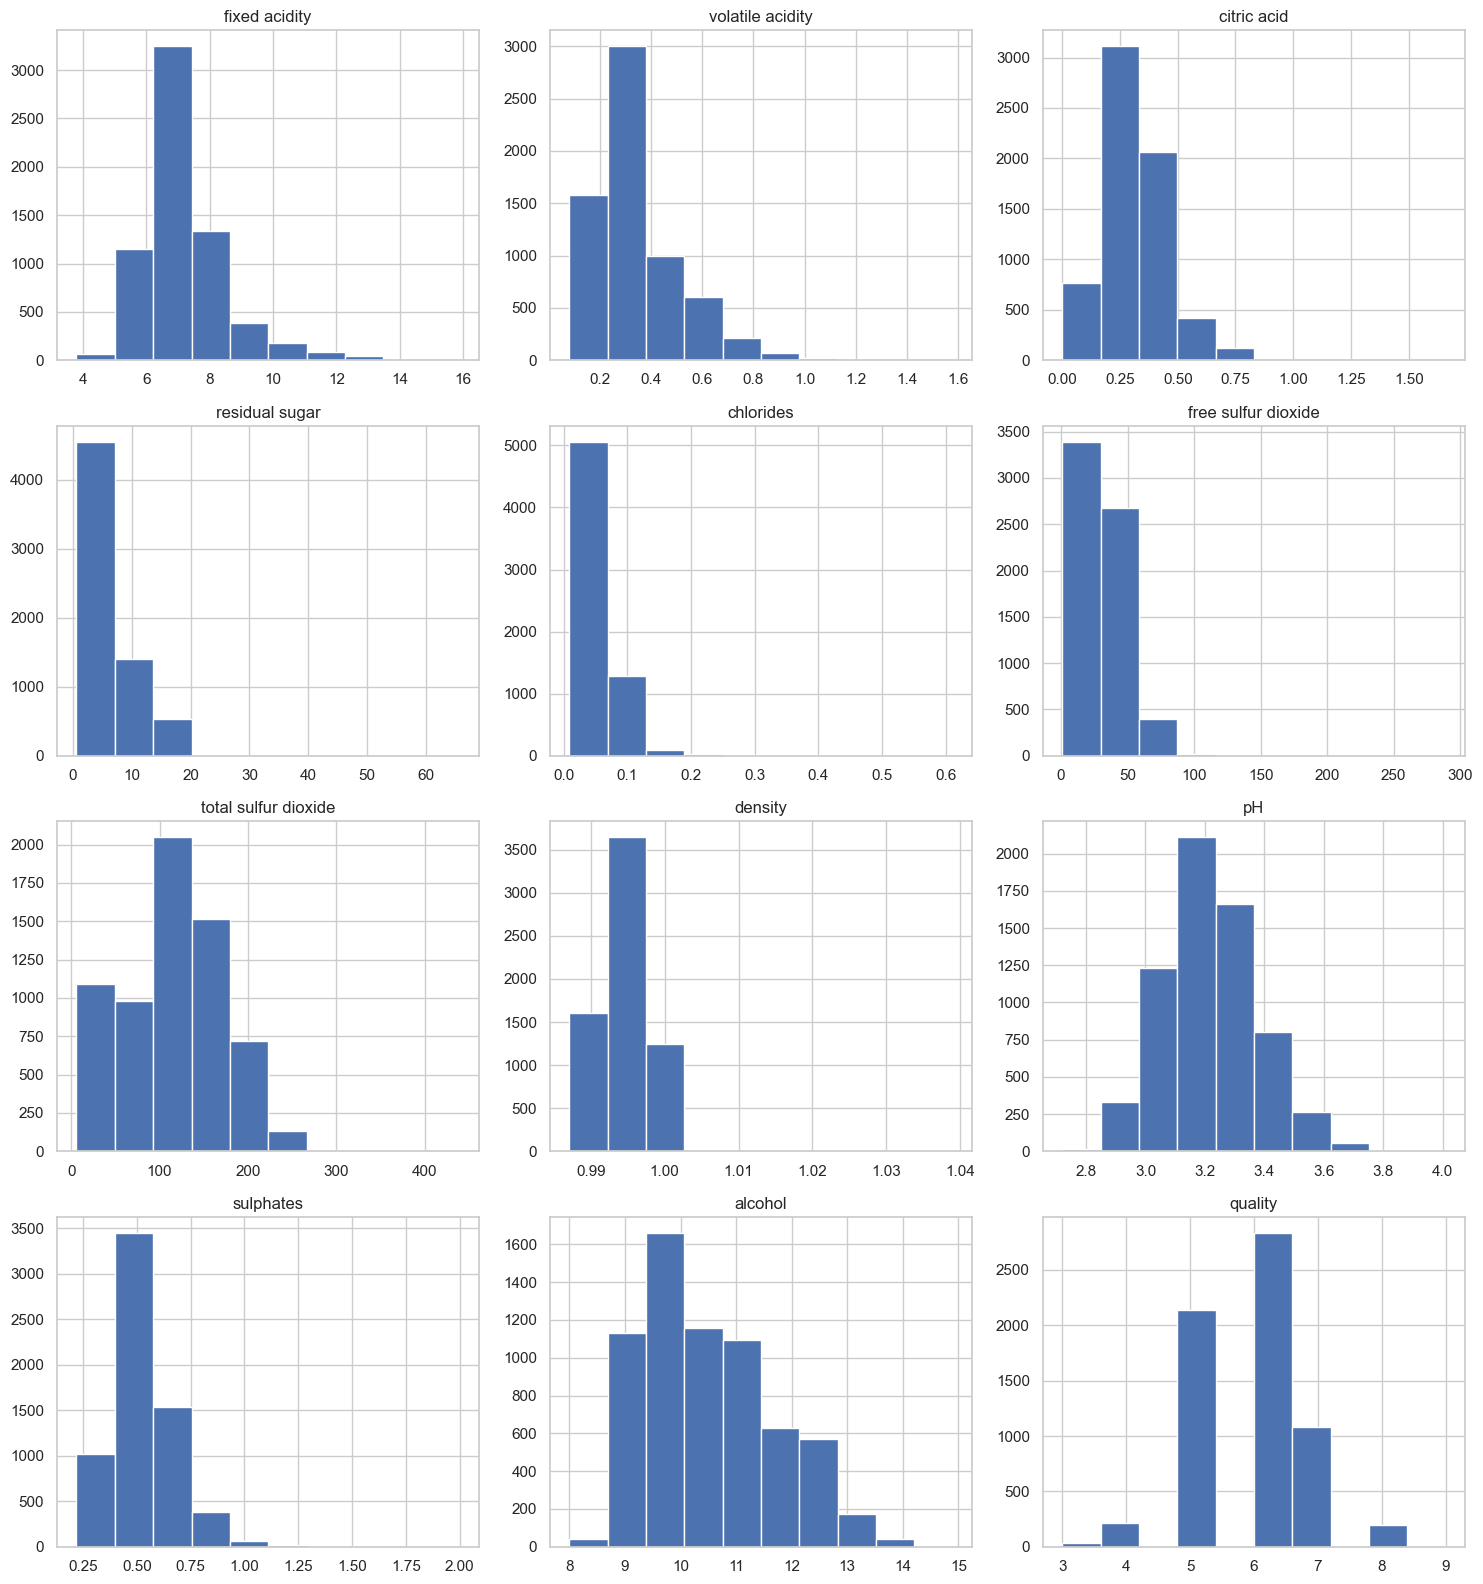

In [250]:
df[numeric_cols].hist(bins=10, figsize=(5*n_cols, 4*n_rows))
plt.tight_layout()

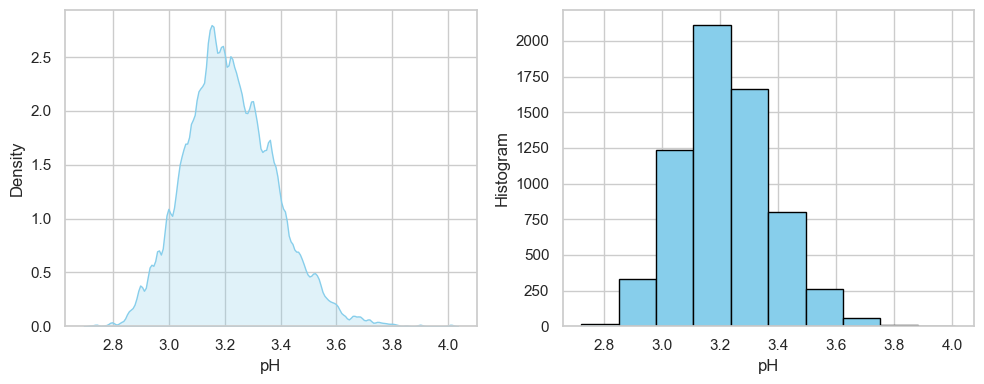

In [251]:
_, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

sns.kdeplot(df['pH'], fill=True, bw_adjust=0.3, color='skyblue', ax=axes[0])
df['pH'].hist(bins=10, color='skyblue', edgecolor='black', ax=axes[1])

axes[1].set_ylabel('Histogram')
axes[1].set_xlabel('pH')
plt.tight_layout()

<Axes: xlabel='pH', ylabel='Density'>

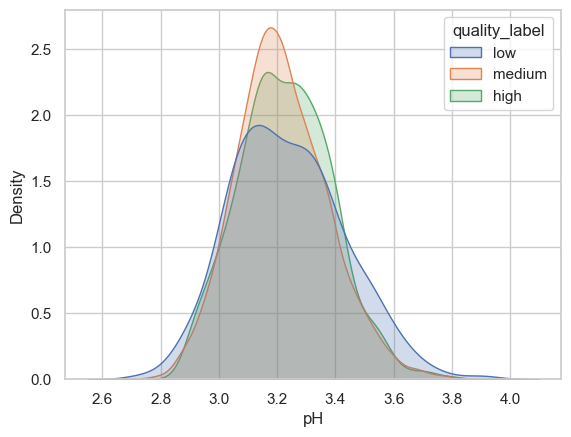

In [252]:
sns.kdeplot(data=df, x='pH', hue='quality_label', fill=True, common_norm=False)

In [253]:
df.shape

(6497, 14)

Text(0.5, 1.0, 'Normalized frequency of Quality')

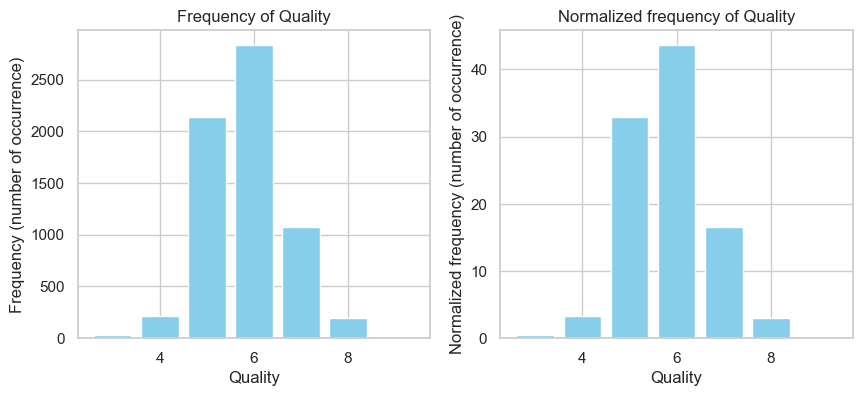

In [254]:
freq = df['quality'].value_counts()
freq_normalized = df['quality'].value_counts(normalize=True) * 100

_, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(freq.index, freq.values, color='skyblue')
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Frequency (number of occurrence)')
axes[0].set_title('Frequency of Quality')

axes[1].bar(freq_normalized.index, freq_normalized.values, color='skyblue')
axes[1].set_xlabel('Quality')
axes[1].set_ylabel('Normalized frequency (number of occurrence)')
axes[1].set_title('Normalized frequency of Quality')

In [255]:
print('Frequency of Quality: \n', freq)
print('-----------------------------')
print('Normalized frequency of Quality: \n', freq_normalized)

Frequency of Quality: 
 quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64
-----------------------------
Normalized frequency of Quality: 
 quality
6    43.650916
5    32.907496
7    16.607665
4     3.324611
8     2.970602
3     0.461752
9     0.076959
Name: proportion, dtype: float64


# Multivariate Analysis

In [256]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,0.219008,0.324436,-0.111981,0.298195,-0.282735,-0.329054,0.458910,-0.252700,0.299568,-0.095452,-0.076743
volatile acidity,0.219008,1.000000,-0.377981,-0.196011,0.377124,-0.352557,-0.414476,0.271296,0.261454,0.225984,-0.037640,-0.265699
citric acid,0.324436,-0.377981,1.000000,0.142451,0.038998,0.133126,0.195242,0.096154,-0.329808,0.056197,-0.010493,0.085532
residual sugar,-0.111981,-0.196011,0.142451,1.000000,-0.128940,0.402871,0.495482,0.552517,-0.267320,-0.185927,-0.359415,-0.036980
chlorides,0.298195,0.377124,0.038998,-0.128940,1.000000,-0.195045,-0.279630,0.362615,0.044708,0.395593,-0.256916,-0.200666
free sulfur dioxide,-0.282735,-0.352557,0.133126,0.402871,-0.195045,1.000000,0.720934,0.025717,-0.145854,-0.188457,-0.179838,0.055463
total sulfur dioxide,-0.329054,-0.414476,0.195242,0.495482,-0.279630,0.720934,1.000000,0.032395,-0.238413,-0.275727,-0.265740,-0.041385
density,0.458910,0.271296,0.096154,0.552517,0.362615,0.025717,0.032395,1.000000,0.011686,0.259478,-0.686745,-0.305858
pH,-0.252700,0.261454,-0.329808,-0.267320,0.044708,-0.145854,-0.238413,0.011686,1.000000,0.192123,0.121248,0.019506
sulphates,0.299568,0.225984,0.056197,-0.185927,0.395593,-0.188457,-0.275727,0.259478,0.192123,1.000000,-0.003029,0.038485


<Axes: >

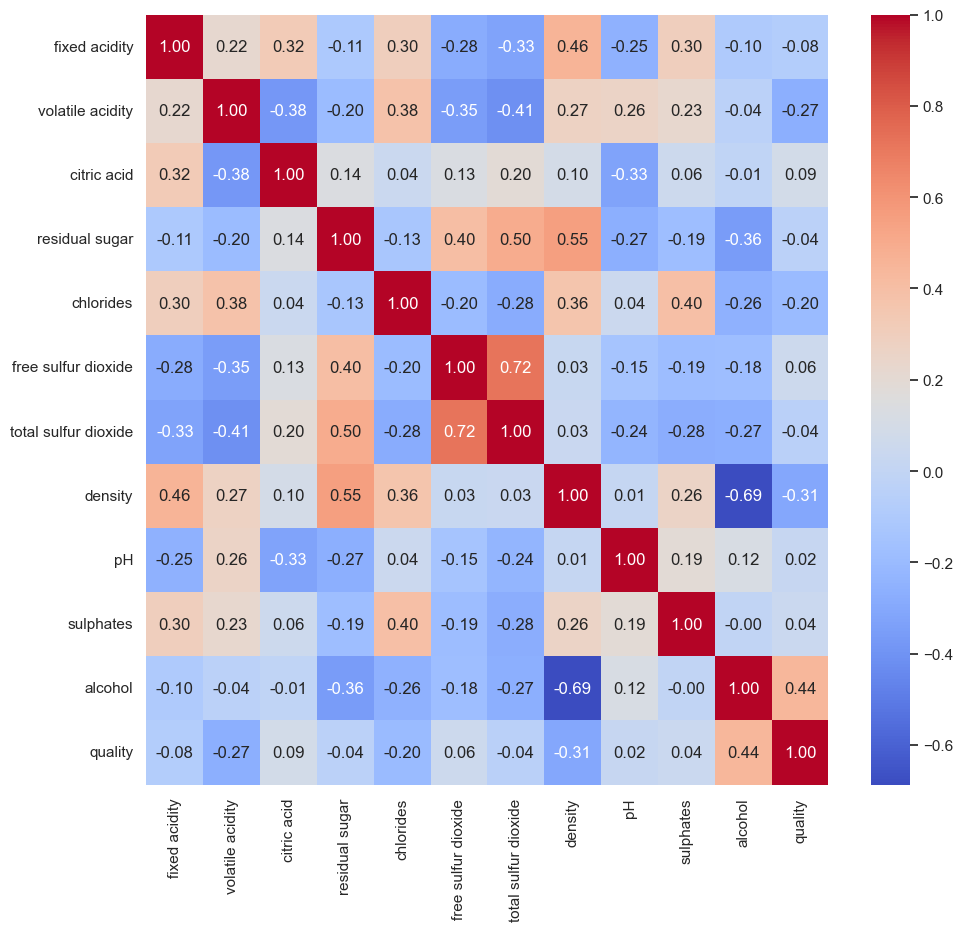

In [257]:
plt.figure(figsize=(11, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

<Axes: >

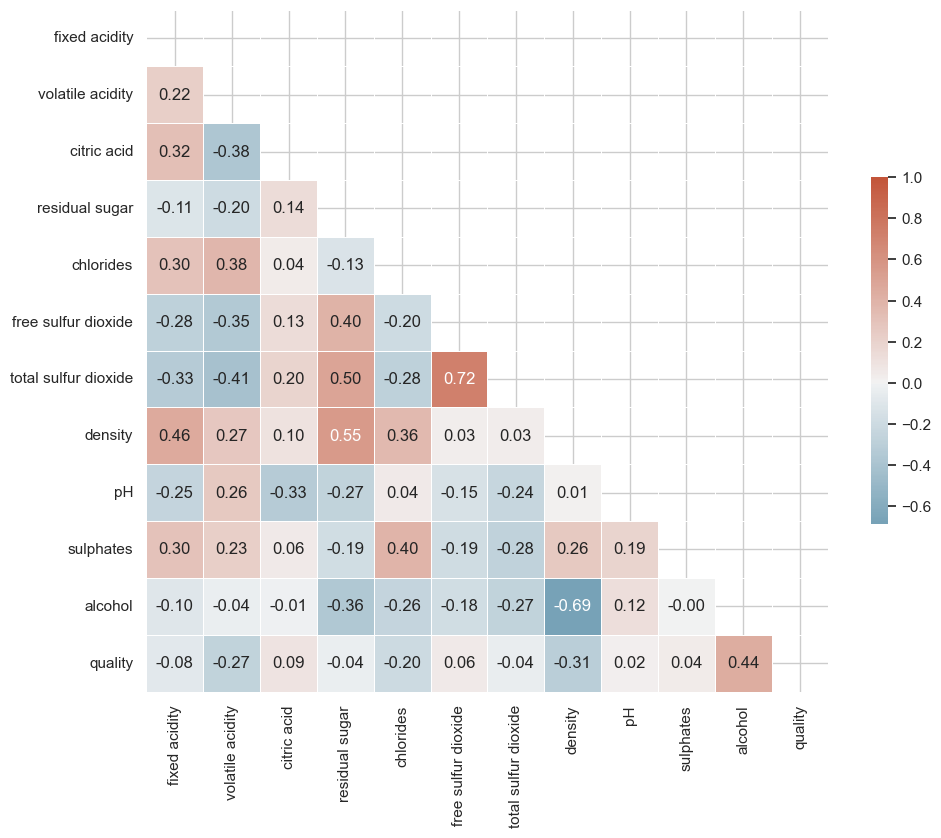

In [258]:
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
f, ax = plt.subplots(figsize=(11, 9))

cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_matrix, annot=True, mask=mask, cmap=cmap, vmax=1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5}, fmt=".2f", ax=ax)

In [259]:
from feature_engine.selection import SmartCorrelatedSelection

selector = SmartCorrelatedSelection(selection_method='variance', threshold=0.7)
selector.fit(df)
selector.correlated_feature_sets_

[{'free sulfur dioxide', 'total sulfur dioxide'}]

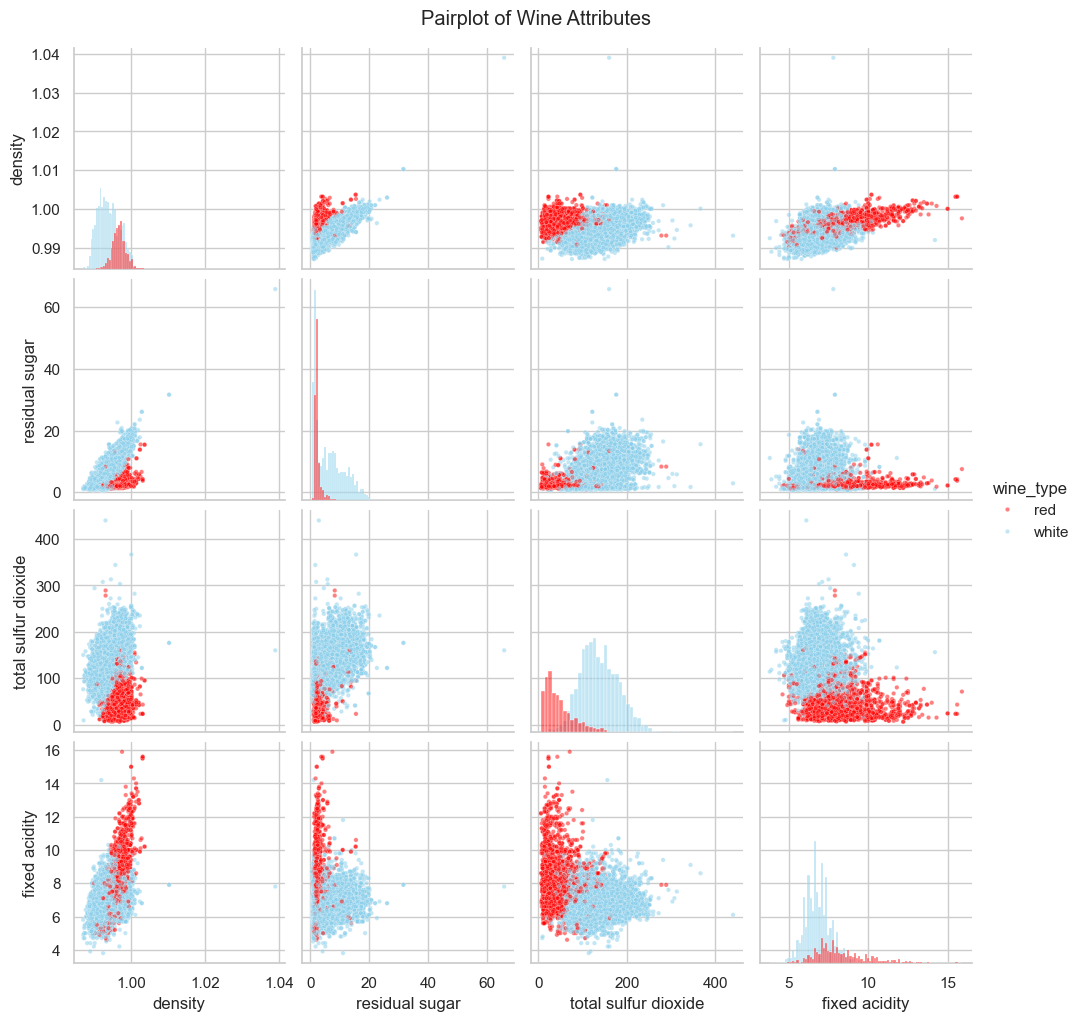

In [260]:
subset_attributes = ['density', 'residual sugar', 'total sulfur dioxide', 'fixed acidity']

sns.pairplot(df[subset_attributes + ['wine_type']], hue='wine_type', diag_kind='hist', palette={'red':'red', 'white':'skyblue'}, plot_kws={'alpha':0.5, 's':10})
plt.suptitle('Pairplot of Wine Attributes', y=1.02)
plt.show()

In [261]:
df['density']

0       0.99960
1       0.99815
2       0.99133
3       0.99570
4       0.99316
         ...   
6492    0.99930
6493    0.99358
6494    1.01030
6495    0.99558
6496    0.99335
Name: density, Length: 6497, dtype: float64

In [262]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

subset_attributes = ['density', 'residual sugar', 'total sulfur dioxide', 'fixed acidity', 'chlorides']

# Something is wrong with this one:
# transformer = ColumnTransformer(
#     transformers=[
#         ('standard_scaler', StandardScaler(), subset_attributes)
#     ],
#     remainder='passthrough'
# )
# df_parallel = pd.DataFrame(transformer.fit_transform(df))
# df_parallel.columns = df.columns

# df_parallel = df_parallel[subset_attributes + ['wine_type']]
# df_parallel.describe()

transformer = ColumnTransformer(
    transformers=[
        ('standard_scaler', StandardScaler(), subset_attributes)
    ],
    remainder='drop'
)
df_parallel = pd.DataFrame(transformer.fit_transform(df), columns=subset_attributes)
df_parallel['wine_type'] = df['wine_type'].values

df_parallel

,density,residual sugar,total sulfur dioxide,fixed acidity,chlorides,wine_type
0,1.635305,-0.723758,-1.694069,3.613801,1.854538,red
1,1.151720,-0.555601,-0.313966,1.376723,1.055244,red
2,-1.122794,-0.891916,0.269924,0.219614,-0.172244,white
3,0.334629,0.474366,0.942282,-0.551792,-0.314975,white
4,-0.512477,-0.618660,1.835810,-0.474652,-0.115152,white
...,...,...,...,...,...,...
6492,1.535253,1.104957,-0.579370,-0.243230,0.484319,red
6493,-0.372405,-0.849877,2.322385,-1.014636,-0.600437,white
6494,5.203824,5.498078,1.066137,0.528176,-0.086605,white
6495,0.294608,0.558444,1.526172,1.299582,-0.914446,white


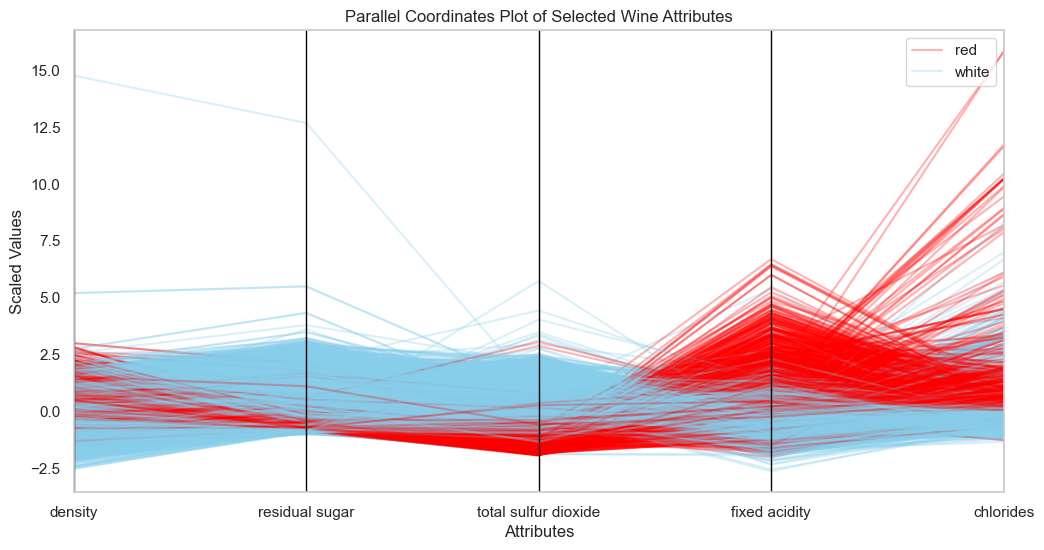

In [263]:
from pandas.plotting import parallel_coordinates

plt.figure(figsize=(12,6))
parallel_coordinates(df_parallel, 'wine_type', color=['red', 'skyblue'], alpha=0.3)
plt.title('Parallel Coordinates Plot of Selected Wine Attributes')
plt.xlabel('Attributes')
plt.ylabel('Scaled Values')
plt.show()

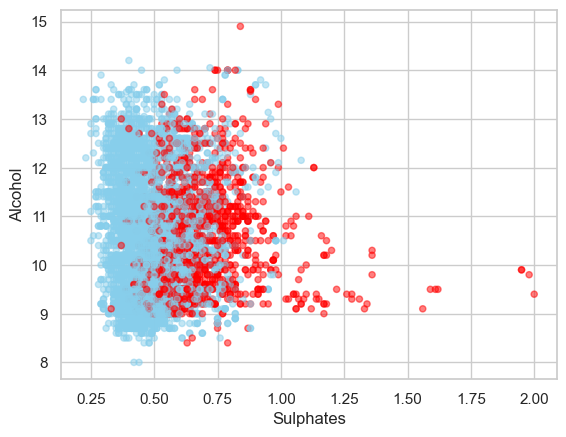

In [264]:
color_map = {'red': 'red', 'white': 'skyblue'}
colors = df['wine_type'].map(color_map)

plt.scatter(
    df['sulphates'],
    df['alcohol'],
    c=df['wine_type'].map({'red': 'red', 'white': 'skyblue'}),
    alpha=0.5,
    s=20
)
plt.xlabel('Sulphates')
plt.ylabel('Alcohol')
plt.show()

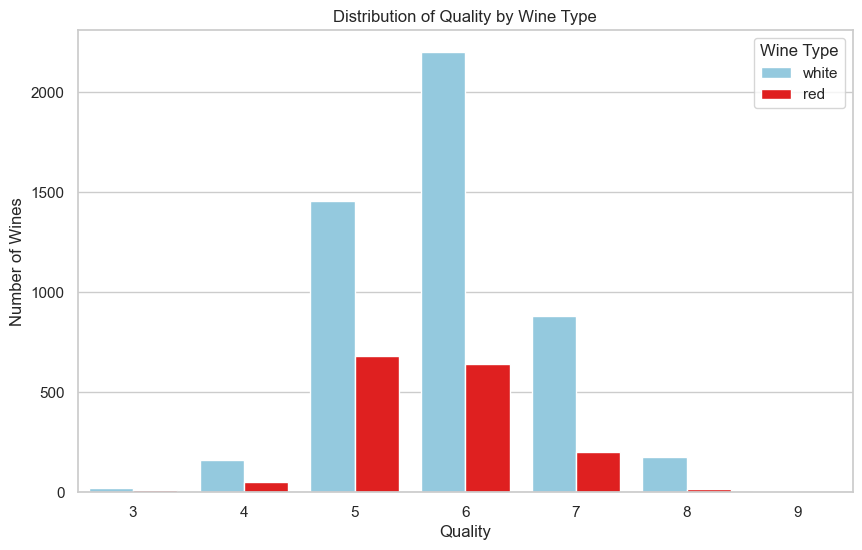

In [265]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='quality', hue='wine_type', palette={'red':'red', 'white':'skyblue'})
plt.title('Distribution of Quality by Wine Type')
plt.xlabel('Quality')
plt.ylabel('Number of Wines')
plt.legend(title='Wine Type')
plt.show()

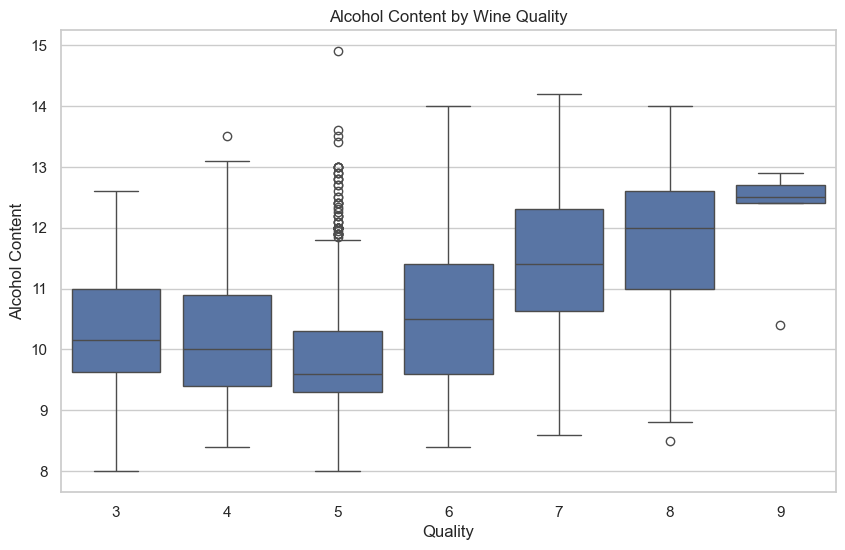

In [266]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x='quality', y='alcohol')

plt.title('Alcohol Content by Wine Quality')
plt.xlabel('Quality')
plt.ylabel('Alcohol Content')
plt.show()

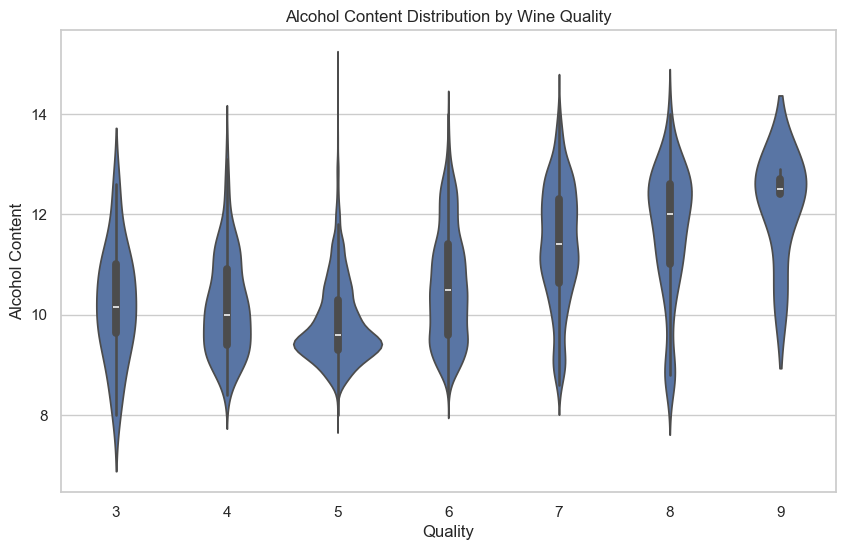

In [267]:
plt.figure(figsize=(10,6))

sns.violinplot(data=df, x='quality', y='alcohol')

plt.title('Alcohol Content Distribution by Wine Quality')
plt.xlabel('Quality')
plt.ylabel('Alcohol Content')
plt.show()

# Multidimensional Visualization

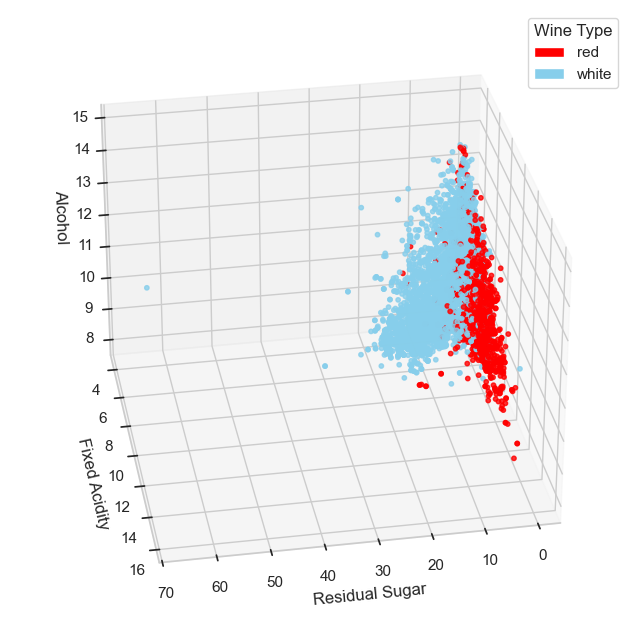

In [268]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['residual sugar'],
    df['fixed acidity'],
    df['alcohol'],
    c=df['wine_type'].map({'red': 'red', 'white': 'skyblue'}),
    s=10,
    alpha=0.8
)

ax.set_xlabel('Residual Sugar')
ax.set_ylabel('Fixed Acidity')
ax.set_zlabel('Alcohol')

legend_elements = [
    Patch(facecolor='red', label='red'),
    Patch(facecolor='skyblue', label='white')
]
ax.legend(handles=legend_elements, title="Wine Type")

ax.view_init(elev=30, azim=80)

plt.show()

In [269]:
corr_matrix['fixed acidity']['alcohol']

-0.09545152256118065

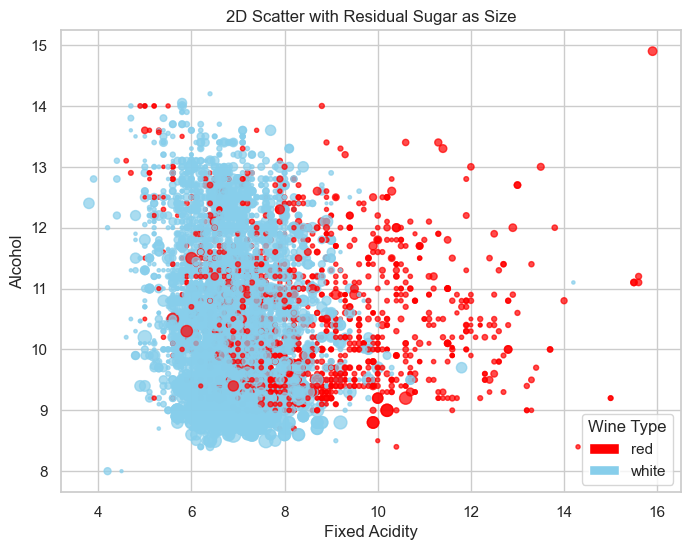

In [270]:
fig, ax = plt.subplots(figsize=(8,6))

scatter = ax.scatter(
    df['fixed acidity'],
    df['alcohol'],
    s=df['residual sugar']*5,
    c=df['wine_type'].map({'red':'red','white':'skyblue'}),
    alpha=0.7
)

ax.set_xlabel('Fixed Acidity')
ax.set_ylabel('Alcohol')
ax.set_title('2D Scatter with Residual Sugar as Size')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='red'),
    Patch(facecolor='skyblue', label='white')
]
ax.legend(handles=legend_elements, title="Wine Type")

plt.show()

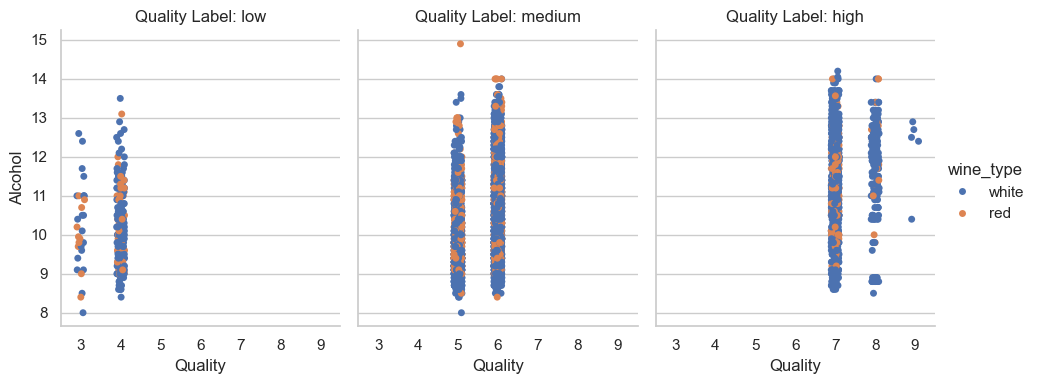

In [271]:

g = sns.catplot(
    data=df,
    x='quality',
    y='alcohol',
    hue='wine_type',
    col='quality_label',
    kind='strip',
    height=4,
    aspect=0.8,
    jitter=True
)

g.set_axis_labels("Quality", "Alcohol")
g.set_titles("Quality Label: {col_name}")
plt.show()